# 14 — Embedding & Attention Weight Analysis

Split from the original combined "Attention Weights, Embeddings & Partial Charge Probe" notebook — this half covers embeddings and attention only. See notebook 15 for the partial charge probe.

Probes the internal representations of a trained model **without modifying any weights**, to understand how attention allocates information across atom types and residues, and whether the model's learned atom embeddings are chemically meaningful.

## Sections

- **1a** Atom-type embedding cosine similarity — do chemically similar elements cluster in embedding space?
- **1b** Per-element attention weights — does the AQ cross-attention differentiate by chemistry, or just by atom abundance?
- **1b-i** Per-residue attention — does amino-acid context modulate attention allocation beyond element identity?
- **1c** Cross-model embedding comparison — do AttentionESPN and DistanceESPN converge to similar atom representations despite different aggregation mechanisms?

## Key Findings (from the original combined run)

The model's attention weights differentiate meaningfully by element and residue context, consistent with learning chemistry rather than attending purely by abundance. See cell outputs below for the actual per-element / per-residue breakdowns from that run.

> **Note:** `EMBED_MODEL`/`COMPARE_MODEL` below point at checkpoints from the old pre-staged-ablation naming (`attention_both_batching`, `distance_both`). Re-point these at the winning Phase 1-4 checkpoints once the staged ablation study concludes, and rerun.

In [6]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path("../..").resolve()))

from src.analysis.embedding_analysis import (
    ELEMENT_NAMES,
    RESIDUE_NAMES,
    collect_attention_stats,
    collect_attention_stats_residue,
    compare_embedding_tables,
    embedding_cosine_sim,
    load_model_frozen,
    _load_graph,
)
from src.analysis.charge_probe import (
    ChargeProbe,
    evaluate_probe,
    extract_atom_embeddings,
    read_pqr_charges,
    read_pqr_atoms,
    train_probe,
)
from src.data.dataset import load_split_manifest
from src.models.attention_espn import AttentionESPN
from src.utils.config import get_data_root
from src.utils.paths import ProteinPaths

## Configuration

`EMBED_MODEL` is the checkpoint used for embedding and attention analysis. `COMPARE_MODEL` is a second checkpoint for cross-model embedding comparison (set to `None` to skip §1c).

In [ ]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = get_data_root()

EMBED_MODEL   = CKPT_ROOT / "attention_both_batching"
# Second model for cross-model comparison (can be None to skip 1c)
COMPARE_MODEL = CKPT_ROOT / "distance_both"

print(f"EMBED_MODEL:   {EMBED_MODEL}  (exists: {EMBED_MODEL.exists()})")
print(f"COMPARE_MODEL: {COMPARE_MODEL}  (exists: {COMPARE_MODEL.exists()})")

---
## 1. Embeddings & Attention Weights

### 1a. Atom-type embedding cosine similarity

Pairwise cosine similarity between the rows of the `AtomEncoder`'s element embedding table. If the model has learned chemically meaningful representations, electronegative elements (O, N) should cluster together and away from carbon; hydrogen should occupy its own region. A near-uniform matrix indicates the embeddings are not well-differentiated by element.

Loaded attention from attention_both_batching
  hidden_dim=256  feature_spec={'query_curvature': True, 'query_normal': True}


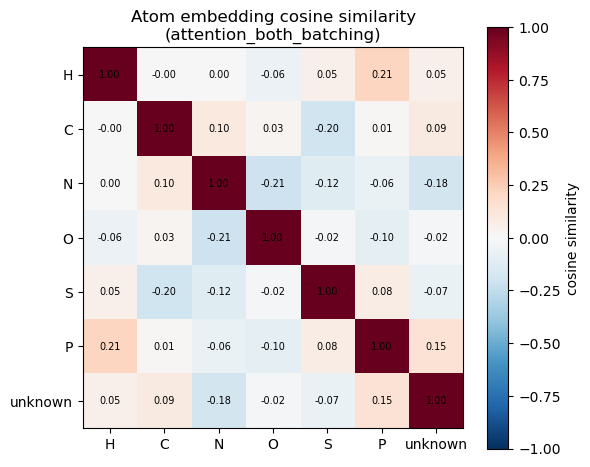

In [8]:
if not EMBED_MODEL.exists():
    print(f"Checkpoint not found: {EMBED_MODEL} — run the sweep first.")
else:
    model_a, ckpt_a = load_model_frozen(EMBED_MODEL, DEVICE)
    print(f"Loaded {ckpt_a['model_name']} from {EMBED_MODEL.name}")
    print(f"  hidden_dim={ckpt_a['model_config']['hidden_dim']}  "
          f"feature_spec={ckpt_a.get('feature_spec', {})}")

    sim, labels = embedding_cosine_sim(model_a)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(sim, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label="cosine similarity")
    ax.set_title(f"Atom embedding cosine similarity\n({EMBED_MODEL.name})")
    plt.tight_layout()
    plt.show()

### 1b. Per-element attention weights

Mean attention weight α per element per head, collected over all AQ edges in the test split. A flat distribution across elements would indicate the model attends purely by geometric proximity (abundance); systematic differentiation by element indicates the model uses atom chemistry to modulate how much information each atom type contributes to a query node's representation.

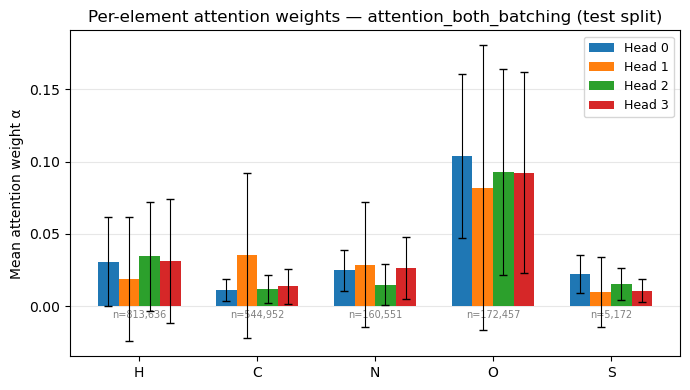


Mean α ± std per element per head  (model=attention_both_batching)


,Element,N edges,Head 0,Head 1,Head 2,Head 3
0,H,813636,0.0307 ± 0.0309,0.0186 ± 0.0432,0.0344 ± 0.0377,0.0311 ± 0.0432
1,C,544952,0.0111 ± 0.0075,0.0350 ± 0.0570,0.0121 ± 0.0097,0.0137 ± 0.0121
2,O,172457,0.1040 ± 0.0567,0.0819 ± 0.0988,0.0930 ± 0.0712,0.0923 ± 0.0695
3,N,160551,0.0248 ± 0.0142,0.0287 ± 0.0432,0.0148 ± 0.0141,0.0264 ± 0.0214
4,S,5172,0.0222 ± 0.0133,0.0098 ± 0.0244,0.0151 ± 0.0112,0.0106 ± 0.0081


In [9]:
if not EMBED_MODEL.exists():
    print(f"Checkpoint not found: {EMBED_MODEL}")
elif not isinstance(model_a, AttentionESPN):
    print(f"{EMBED_MODEL.name} is a distance model — no cross-attention to inspect.")
else:
    _, _, test_ids = load_split_manifest(DATA_ROOT)
    print(f"Collecting attention stats over {len(test_ids)} test proteins...")
    attn_stats = collect_attention_stats(model_a, test_ids, DATA_ROOT, DEVICE)

    present   = [(name, attn_stats[name]) for name in ELEMENT_NAMES if attn_stats[name]["count"] > 0]
    names     = [p[0] for p in present]
    means_arr = np.array([p[1]["mean"] for p in present])
    stds_arr  = np.array([p[1]["std"]  for p in present])
    counts    = [p[1]["count"] for p in present]
    n_heads   = means_arr.shape[1]

    fig, ax = plt.subplots(figsize=(max(7, len(names)), 4))
    total_width = 0.7
    bar_w = total_width / n_heads
    x = np.arange(len(names))
    for h in range(n_heads):
        offsets = x + h * bar_w - total_width / 2 + bar_w / 2
        ax.bar(offsets, means_arr[:, h], width=bar_w, label=f"Head {h}", zorder=3)
        ax.errorbar(offsets, means_arr[:, h], yerr=stds_arr[:, h],
                    fmt="none", color="black", capsize=3, linewidth=0.8, zorder=4)
    for i, (xi, cnt) in enumerate(zip(x, counts)):
        ax.text(xi, -0.003, f"n={cnt:,}", ha="center", va="top", fontsize=7, color="gray")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel("Mean attention weight α")
    ax.set_title(f"Per-element attention weights — {EMBED_MODEL.name} (test split)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

    rows_el = []
    for name, s in present:
        row = {"Element": name, "N edges": s["count"]}
        for h, (m, sd) in enumerate(zip(s["mean"], s["std"])):
            row[f"Head {h}"] = f"{m:.4f} ± {sd:.4f}"
        rows_el.append(row)
    df_el = pd.DataFrame(rows_el).sort_values("N edges", ascending=False)
    print(f"\nMean α ± std per element per head  (model={EMBED_MODEL.name})")
    display(df_el.reset_index(drop=True))

#### 1b-i. Attention weights — residue × head heatmap

Does the model attend differently to atoms depending on which amino acid they belong to?
A uniform heatmap suggests element identity matters more than residue context.

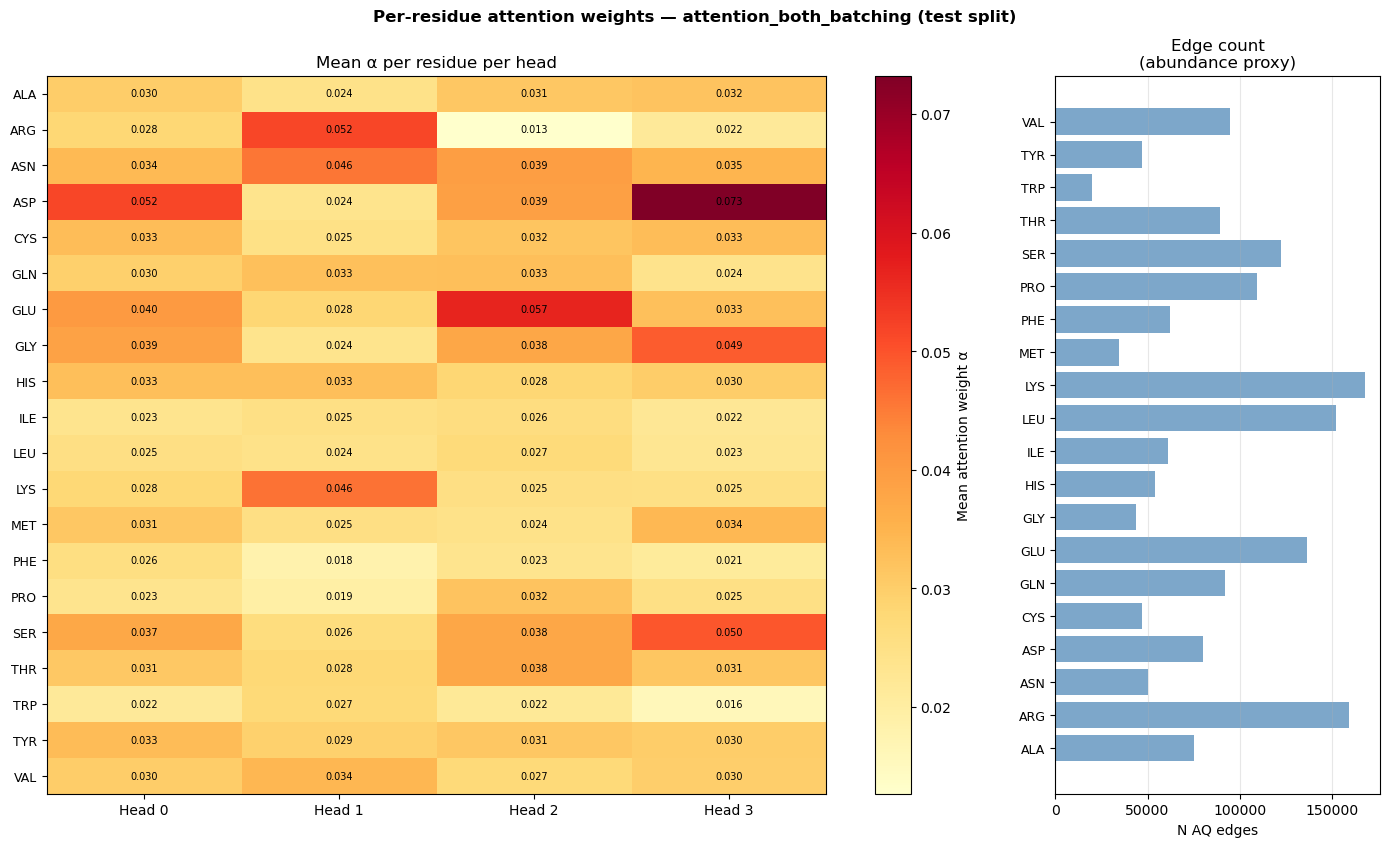


Mean α ± std per residue per head  (model=attention_both_batching)


,Residue,N edges,Head 0,Head 1,Head 2,Head 3
0,LYS,167506,0.0276 ± 0.0305,0.0462 ± 0.0657,0.0254 ± 0.0288,0.0250 ± 0.0284
1,ARG,158854,0.0279 ± 0.0331,0.0517 ± 0.0743,0.0127 ± 0.0235,0.0216 ± 0.0395
2,LEU,152016,0.0253 ± 0.0287,0.0244 ± 0.0483,0.0270 ± 0.0358,0.0227 ± 0.0335
3,GLU,136304,0.0401 ± 0.0530,0.0282 ± 0.0678,0.0566 ± 0.0736,0.0326 ± 0.0454
4,SER,122064,0.0373 ± 0.0426,0.0263 ± 0.0458,0.0377 ± 0.0456,0.0495 ± 0.0534
5,PRO,109360,0.0234 ± 0.0290,0.0195 ± 0.0421,0.0320 ± 0.0333,0.0251 ± 0.0260
6,VAL,94415,0.0301 ± 0.0338,0.0343 ± 0.0594,0.0272 ± 0.0332,0.0298 ± 0.0406
7,GLN,92183,0.0296 ± 0.0356,0.0326 ± 0.0686,0.0330 ± 0.0357,0.0239 ± 0.0224
8,THR,89421,0.0310 ± 0.0377,0.0278 ± 0.0538,0.0375 ± 0.0536,0.0315 ± 0.0399
9,ASP,79940,0.0516 ± 0.0564,0.0237 ± 0.0517,0.0391 ± 0.0405,0.0732 ± 0.0880


In [10]:
if not EMBED_MODEL.exists():
    print(f"Checkpoint not found: {EMBED_MODEL}")
elif not isinstance(model_a, AttentionESPN):
    print(f"{EMBED_MODEL.name} is a distance model — no cross-attention.")
else:
    _, _, test_ids = load_split_manifest(DATA_ROOT)
    print(f"Collecting residue-level attention stats over {len(test_ids)} test proteins...")
    res_stats = collect_attention_stats_residue(model_a, test_ids, DATA_ROOT, DEVICE)

    present_res = [(name, res_stats[name]) for name in RESIDUE_NAMES if res_stats[name]["count"] > 0]
    res_names_p = [p[0] for p in present_res]
    res_means   = np.array([p[1]["mean"] for p in present_res])
    res_counts  = [p[1]["count"] for p in present_res]
    n_heads_r   = res_means.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(res_names_p) * 0.38 + 1)),
                             gridspec_kw={"width_ratios": [3, 1]})
    fig.suptitle(f"Per-residue attention weights — {EMBED_MODEL.name} (test split)",
                 fontsize=12, fontweight="bold")

    ax = axes[0]
    im = ax.imshow(res_means, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(n_heads_r))
    ax.set_xticklabels([f"Head {h}" for h in range(n_heads_r)], fontsize=10)
    ax.set_yticks(range(len(res_names_p)))
    ax.set_yticklabels(res_names_p, fontsize=9)
    for i in range(len(res_names_p)):
        for j in range(n_heads_r):
            ax.text(j, i, f"{res_means[i, j]:.3f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label="Mean attention weight α")
    ax.set_title("Mean α per residue per head")

    ax = axes[1]
    y = np.arange(len(res_names_p))
    ax.barh(y, res_counts, color="steelblue", alpha=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(res_names_p, fontsize=9)
    ax.set_xlabel("N AQ edges")
    ax.set_title("Edge count\n(abundance proxy)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    rows_res = []
    for name, s in present_res:
        row = {"Residue": name, "N edges": s["count"]}
        for h, (m, sd) in enumerate(zip(s["mean"], s["std"])):
            row[f"Head {h}"] = f"{m:.4f} ± {sd:.4f}"
        rows_res.append(row)
    df_res = pd.DataFrame(rows_res).sort_values("N edges", ascending=False)
    print(f"\nMean α ± std per residue per head  (model={EMBED_MODEL.name})")
    display(df_res.reset_index(drop=True))

### 1c. Cross-model embedding comparison

Per-element cosine similarity between the `AtomEncoder` embedding tables of the attention and distance models. High similarity across elements indicates both models converged to similar atom representations despite different Stage 2 aggregation mechanisms — suggesting the encoder and Stage 1 rounds are the primary drivers of atom representation quality, not the AQ aggregation style.

Loaded distance from distance_both


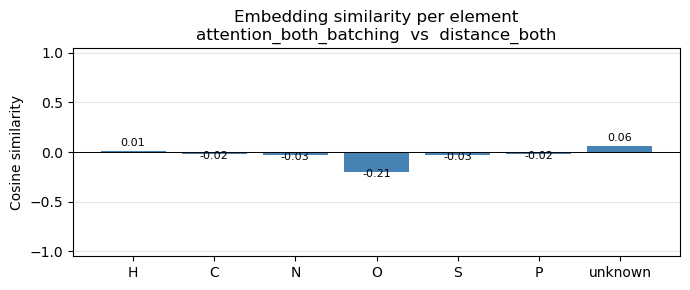

In [11]:
if not EMBED_MODEL.exists() or not COMPARE_MODEL.exists():
    missing = [p for p in [EMBED_MODEL, COMPARE_MODEL] if not p.exists()]
    print(f"Skipping — checkpoint(s) not found: {[p.name for p in missing]}")
else:
    model_b, ckpt_b = load_model_frozen(COMPARE_MODEL, DEVICE)
    print(f"Loaded {ckpt_b['model_name']} from {COMPARE_MODEL.name}")

    sims = compare_embedding_tables(model_a, model_b)

    fig, ax = plt.subplots(figsize=(7, 3))
    x    = np.arange(len(ELEMENT_NAMES))
    bars = ax.bar(x, sims, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(ELEMENT_NAMES)
    ax.set_ylim(-1.05, 1.05)
    ax.axhline(0, color="k", linewidth=0.7)
    ax.set_ylabel("Cosine similarity")
    ax.set_title(f"Embedding similarity per element\n{EMBED_MODEL.name}  vs  {COMPARE_MODEL.name}")
    for bar, val in zip(bars, sims):
        offset = 0.03 if val >= 0 else -0.07
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()